# Generic Gaussian fitting
Fits an arbitrary number of Gaussian profiles to 1D data.  The number of peaks is optimised to best suit the input profile.

In [1]:
# Importing libraries
from kymotools.detect import Detector

import csv
import kymotools.io as kio
import numpy as np
import os

/Users/gfisher/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Documents/Papers/Fisher and Voulgaris et al 2025/Scripts used/.pixi/envs/default/lib/python3.12/site-packages/kymotools/io.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# Parameters
input_path = "./examples/input/" # Path to folder containing CSVs to process
output_path = "./examples/output/" # Path to folder in which to save output

In [3]:
def process(input_path, output_path, name):
    with open(input_path+name, mode ='r') as file:
        # Reading values from CSV file into a lists
        vals_list = []
        
        for line in csv.reader(file):
            try:
                float(line[0])       
            except:
                continue

            vals_list.append(float(line[0]))

        # Converting list to Numpy array
        vals = np.array(vals_list)
        
        # Initialising Detector
        detector = Detector(half_t_w=0,peak_det_thresh = 0.1, n_max=1, a_lb = 0.5, c_lb=1, c_ub=6, c_def=4)
        peaks, rmse = detector.fit_peaks(vals)

        # Displaying and saving Gaussian fit
        rootname = os.path.splitext(name)[0]
        fig = kio.plot_gauss_for_frame(peaks,0, vals=vals)
        fig.savefig(output_path+rootname+"_peaks.png")
                        
        # Saving peak data (position, sigma, etc.)
        kio.write_peak_data(peaks, output_path+rootname+"_peaks.csv")
    

Processing:  Gaussian_example


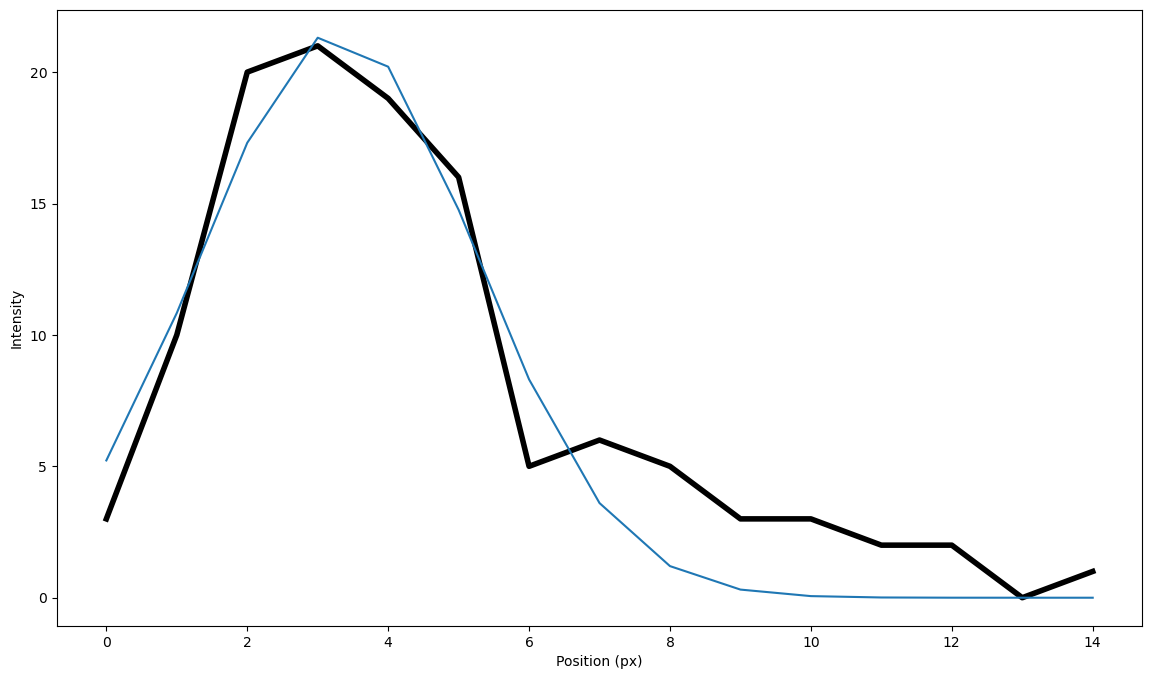

In [ ]:
# Batch processing all csv files in input folder
for name in os.listdir(input_path):
    print("Processing: ",name)
    if os.path.splitext(name)[1] == ".csv" and "peaks" not in name:
        process(input_path, output_path, name)